<a href="https://colab.research.google.com/github/maclandrol/cours-ia-med/blob/master/05_Analyse_Radiographies_Thoraciques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05. Analyse de Radiographies Thoraciques

**Enseignant:** Emmanuel Noutahi, PhD

---

## Objectifs

- Utiliser TorchXRayVision pour détecter 18 pathologies thoraciques
- Charger et analyser des radiographies
- Comprendre les limites: qualité d'image et pathologies hors distribution

## Pathologies Détectables (18)

Atélectasie, Cardiomégalie, Épanchement, Infiltration, Masse, Nodule, Pneumonie, Pneumothorax, Consolidation, Œdème, Emphysème, Fibrose, Épaississement pleural, Hernie, Opacité pulmonaire, Lésion pleurale, Fracture, Dispositif médical

## 1. Installation

In [1]:
!pip install -q torchxrayvision torch torchvision scikit-image pillow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 46.1 MB/s eta 0:00:00


In [141]:
import torchxrayvision as xrv
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage import transform as sktransform, util, exposure, filters, io as skio
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cuda


## 2. Chargement du Modèle

In [3]:
model = xrv.models.DenseNet(weights="densenet121-res224-all")
model = model.to(device)
model.eval()

print(f"Pathologies détectables ({len(model.pathologies)}):")
for i, p in enumerate(model.pathologies, 1):
    print(f"{i:2d}. {p}")

If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt -O /root/.torchxrayvision/models_data/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt`
[██████████████████████████████████████████████████]
Pathologies détectables (18):
 1. Atelectasis
 2. Consolidation
 3. Infiltration
 4. Pneumothorax
 5. Edema
 6. Emphysema
 7. Fibrosis
 8. Effusion
 9. Pneumonia
10. Pleural_Thickening
11. Cardiomegaly
12. Nodule
13. Mass
14. Hernia
15. Lung Lesion
16. Fracture
17. Lung Opacity
18. Enlarged Cardiomediastinum


## 3. Fonctions Utilitaires

In [142]:
# Transformations standard
transform = torchvision.transforms.Compose([
    xrv.datasets.XRayCenterCrop(),
    xrv.datasets.XRayResizer(224),
])

def prepare_image(img_input, from_file=True, apply_fn=None):
    """
    Prépare une image pour le modèle.

    Args:
        img_input: chemin du fichier (si from_file=True) ou array numpy
        from_file: si True, charge depuis fichier, sinon utilise l'array directement
        apply_fn: fonction de transformation à appliquer

    Returns:
        tensor: image préparée pour le modèle
    """
    if from_file:
        img = skio.imread(img_input)
    else:
        img = img_input

    if apply_fn is not None:
      img = apply_fn(img)
    # Normaliser
    img = xrv.datasets.normalize(img, 255)

    # Check that images are 2D arrays
    if len(img.shape) > 2:
        img = img[:, :, 0]
    if len(img.shape) < 2:
        print("error, dimension lower than 2 for image")

    # Add color channel
    img = img[None, :, :]
    img = transform(img)

    # Convertir en tensor
    img_tensor = torch.from_numpy(img).to(device)
    return img_tensor

def show_image(img_tensor):
    """Montrer une image en format tensor comme figure"""
    plt.figure(figsize=(6, 6))
    if len(img_tensor.shape) == 3:
        img_tensor = img_tensor[0]
    plt.imshow(img_tensor.cpu(), cmap='gray')
    plt.title("Votre Image")
    plt.axis('off')
    plt.show()

## 4. Chargement d'Images

### Option A: Depuis un Dataset TorchXRayVision

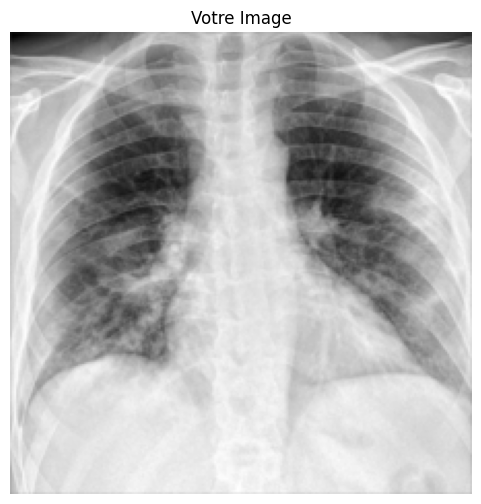

In [188]:
# Tenter de charger un dataset
import io
# Load image from internet
url = "https://raw.githubusercontent.com/mlmed/torchxrayvision/master/tests/16747_3_1.jpg"
main_img = prepare_image(url, from_file=True)
show_image(main_img)



## 5. Analyse de l'Image

In [59]:

def predict(img_tensor, model=model):
    """
    Prédit les pathologies sur une radiographie.

    Args:
        img_tensor: tensor de l'image préparée
        model: modèle TorchXRayVision

    Returns:
        probs: probabilités pour chaque pathologie
        indices: indices triés par probabilité décroissante
    """
    with torch.no_grad():
        pred = model(img_tensor.unsqueeze(0)).cpu()[0].detach().numpy()

    indices = np.argsort(pred)[::-1]
    return pred, indices


In [156]:
# Prédiction
scores, indices = predict(main_img, model)
top_k = 10
for idx in indices[:top_k]:
    pathology = model.pathologies[idx]
    prob = scores[idx]
    bar = '█' * int(prob * 30)
    print(f"{pathology:<25} {prob:>6.1%} {bar}")

Nodule                     69.0% ████████████████████
Mass                       63.9% ███████████████████
Lung Opacity               59.1% █████████████████
Infiltration               53.2% ███████████████
Fracture                   51.9% ███████████████
Fibrosis                   51.9% ███████████████
Emphysema                  50.1% ███████████████
Consolidation              42.9% ████████████
Cardiomegaly               36.5% ██████████
Atelectasis                32.8% █████████


## 6. Visualisation

In [157]:
def visualize_results(img_tensor, probs, indices, model=model, top_n=8):
    """
    Visualise l'image et les prédictions.

    Args:
        img_tensor: tensor de l'image
        probs: probabilités
        indices: indices triés
        model: modèle (pour les noms de pathologies)
        top_n: nombre de pathologies à afficher
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Image
    ax1.imshow(img_tensor[0].detach().cpu().numpy(), cmap="gray")
    ax1.set_title("Chest X-ray")
    ax1.axis("off")

    # Top predictions
    top_indices = indices[:top_n]
    top_pathologies = [model.pathologies[i] for i in top_indices]
    top_scores = [scores[i] for i in top_indices]

    ax2.barh(range(top_n), top_scores)
    ax2.set_yticks(range(top_n))
    ax2.set_yticklabels(top_pathologies)
    ax2.set_xlabel("Model score")
    ax2.set_title("Top findings")
    ax2.invert_yaxis()
    ax2.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()


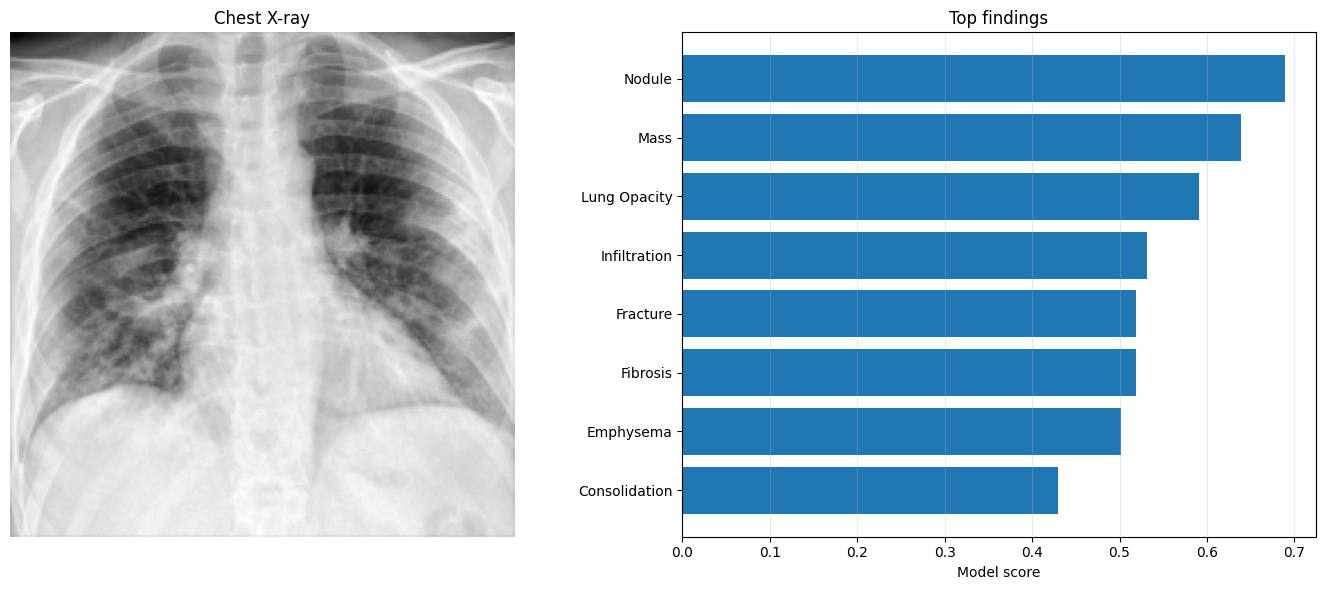

In [158]:
visualize_results(main_img, scores, indices, model, top_n=8)

## 7. Impact des Distorsions d'Image

In [222]:
def ensure_grayscale_2d(img):
    """
    Force une image en format 2D [H, W].
    """
    img = np.asarray(img)

    if img.ndim == 2:
        return img

    if img.ndim == 3:
        # Si image couleur [H, W, C]
        return img[..., :3].mean(axis=2)

    raise ValueError(f"Format image non supporté: shape={img.shape}")


def rotate_image(img, angle):
    img = ensure_grayscale_2d(img).astype(np.float32)
    return sktransform.rotate(
        img, angle, mode="edge", preserve_range=True
    ).astype(np.float32)

def zoom_in_image(img, crop_ratio=0.7):
    img = ensure_grayscale_2d(img).astype(np.float32)
    h, w = img.shape
    crop_h, crop_w = int(h * crop_ratio), int(w * crop_ratio)
    y0 = (h - crop_h) // 2
    x0 = (w - crop_w) // 2
    cropped = img[y0:y0 + crop_h, x0:x0 + crop_w]

    return sktransform.resize(
        cropped, (h, w), preserve_range=True, anti_aliasing=True
    ).astype(np.float32)

def shear_image(img, shear_deg=10):
    img = ensure_grayscale_2d(img).astype(np.float32)
    tform = sktransform.AffineTransform(shear=np.deg2rad(shear_deg))
    return sktransform.warp(
        img, tform.inverse, mode="edge", preserve_range=True
    ).astype(np.float32)

def gaussian_noise_image(img, var=0.01):
    img = ensure_grayscale_2d(img).astype(np.float32)
    img01 = img / 255.0
    noisy = util.random_noise(img01, mode="gaussian", var=var)
    return (noisy * 255.0).astype(np.float32)

def gaussian_blur_image(img, sigma=1.5):
    img = ensure_grayscale_2d(img).astype(np.float32)
    return filters.gaussian(
        img, sigma=sigma, preserve_range=True
    ).astype(np.float32)

def low_contrast_image(img, factor=0.5):
    img = ensure_grayscale_2d(img).astype(np.float32)
    mean_val = img.mean()
    return np.clip((img - mean_val) * factor + mean_val, 0, 255).astype(np.float32)

def high_contrast_image(img, factor=1.5):
    img = ensure_grayscale_2d(img).astype(np.float32)
    mean_val = img.mean()
    return np.clip((img - mean_val) * factor + mean_val, 0, 255).astype(np.float32)

def gamma_dark_image(img, gamma=1.5):
    img = ensure_grayscale_2d(img).astype(np.float32)
    img01 = np.clip(img / 255.0, 0, 1)
    out = exposure.adjust_gamma(img01, gamma=gamma)
    return (out * 255.0).astype(np.float32)

def gamma_bright_image(img, gamma=0.7):
    img = ensure_grayscale_2d(img).astype(np.float32)
    img01 = np.clip(img / 255.0, 0, 1)
    out = exposure.adjust_gamma(img01, gamma=gamma)
    return (out * 255.0).astype(np.float32)

def clahe_image(img, clip_limit=0.02):
    img = ensure_grayscale_2d(img).astype(np.float32)
    img01 = np.clip(img / 255.0, 0, 1)
    out = exposure.equalize_adapthist(img01, clip_limit=clip_limit)
    return (out * 255.0).astype(np.float32)

def central_occlusion_image(img, frac=0.25):
    img = ensure_grayscale_2d(img).astype(np.float32)
    h, w = img.shape
    occ = img.copy()
    occ_h, occ_w = int(h * frac), int(w * frac)
    oy = (h - occ_h) // 2
    ox = (w - occ_w) // 2
    occ[oy:oy + occ_h, ox:ox + occ_w] = occ.mean()
    return occ.astype(np.float32)

In [212]:
import skimage.io as skio
img = skio.imread(url)
# Charger l'image brute
distortions = {
    "Original": prepare_image(img, from_file=False),
    "Rotation +30°": prepare_image(rotate_image(img, 45), from_file=False),
    "Zoom In": prepare_image(zoom_in_image(img, crop_ratio=0.7), from_file=False),
    "Shear": prepare_image(shear_image(img, shear_deg=10), from_file=False),
    "Gaussian Noise": prepare_image(gaussian_noise_image(img, var=0.5), from_file=False),
    "Gaussian Blur": prepare_image(gaussian_blur_image(img, sigma=1.5), from_file=False),
    "Low Contrast": prepare_image(low_contrast_image(img, factor=0.5), from_file=False),
    "High Contrast": prepare_image(high_contrast_image(img, factor=1.7), from_file=False),
    "Gamma Dark": prepare_image(gamma_dark_image(img, gamma=1.5), from_file=False),
    "Gamma Bright": prepare_image(gamma_bright_image(img, gamma=0.7), from_file=False),
    "CLAHE": prepare_image(clahe_image(img, clip_limit=0.02), from_file=False),
    "Central Occlusion": prepare_image(central_occlusion_image(img, frac=0.25), from_file=False),
}

In [213]:
def show_distortions(distortions, ncols=5):
    names = list(distortions.keys())
    n = len(names)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
    axes = np.array(axes).reshape(-1)

    for ax, name in zip(axes, names):
        img = distortions[name]

        # gérer tensor ou numpy
        if torch.is_tensor(img):
            img = img.detach().cpu().numpy()

        # enlever le canal si [1,H,W]
        if img.ndim == 3 and img.shape[0] == 1:
            img = img[0]

        ax.imshow(img, cmap="gray")
        ax.set_title(name)
        ax.axis("off")

    # cacher les axes inutilisés
    for ax in axes[len(names):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

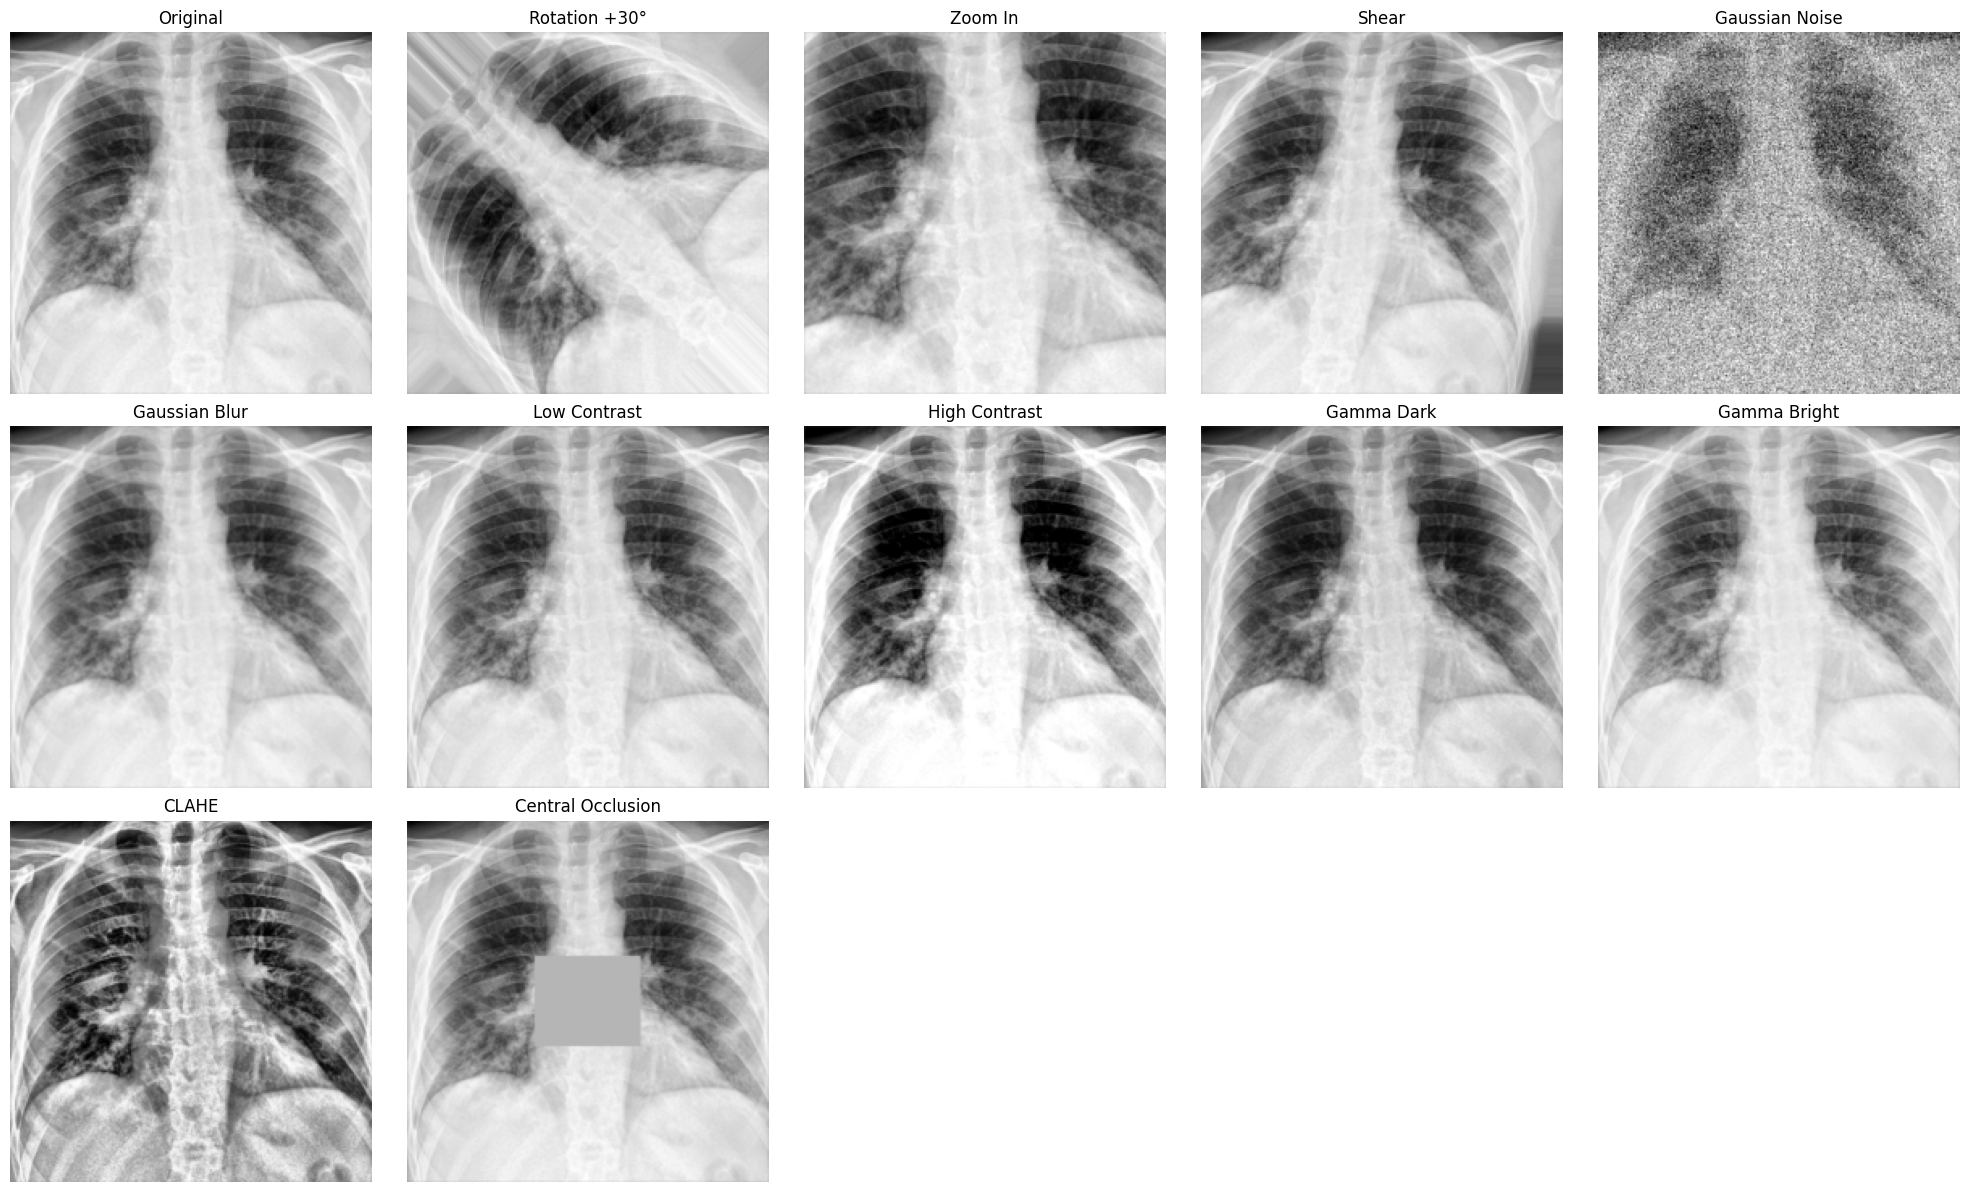

In [214]:
show_distortions(distortions)

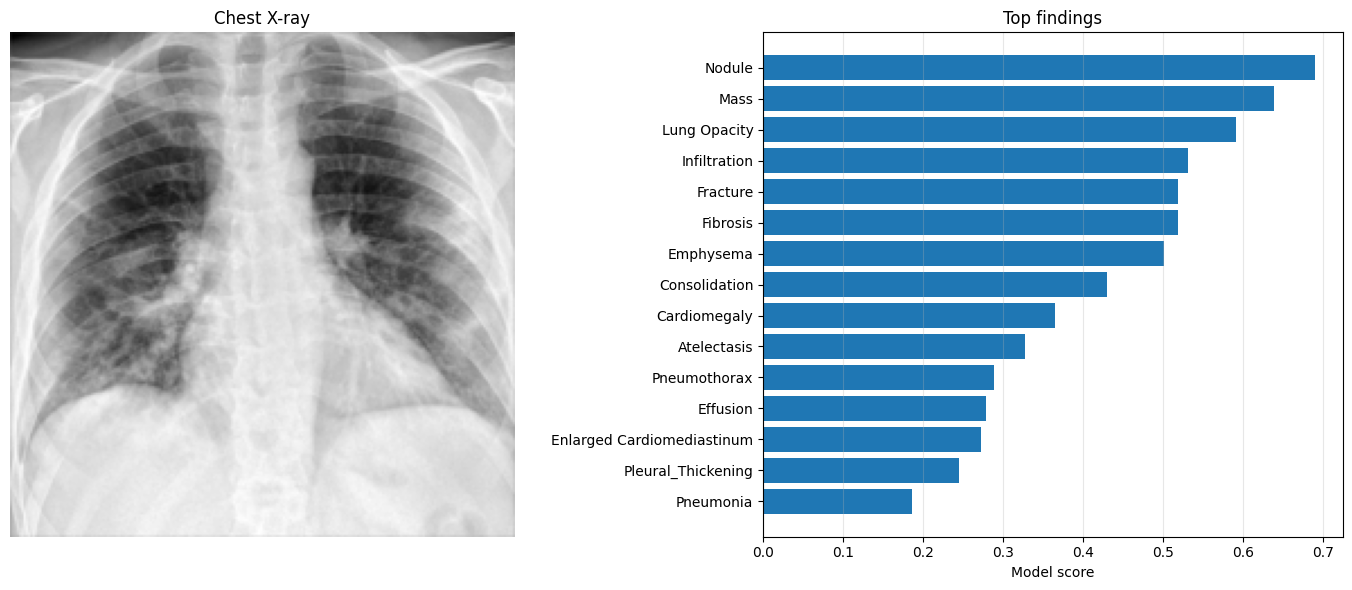

In [215]:
original_image = distortions['Original']
scores, indices = predict(original_image, model)
visualize_results(original_image, scores, indices, top_n=15)

In [216]:
original_image

tensor([[[-712.1519, -765.8649, -753.2164,  ..., -505.6017, -514.5600,
          -465.3788],
         [-730.9327, -808.7698, -798.1855,  ..., -526.4869, -528.5553,
          -465.0344],
         [-704.1196, -772.3271, -750.3226,  ..., -369.3554, -368.5600,
          -357.1478],
         ...,
         [ 395.9654,  488.1383,  541.9443,  ...,  680.2510,  664.1034,
           590.5713],
         [ 390.0197,  471.2682,  522.7174,  ...,  689.7271,  679.8658,
           585.5476],
         [ 355.9199,  428.2425,  472.2276,  ...,  602.7346,  600.4752,
           519.4819]]], device='cuda:0')

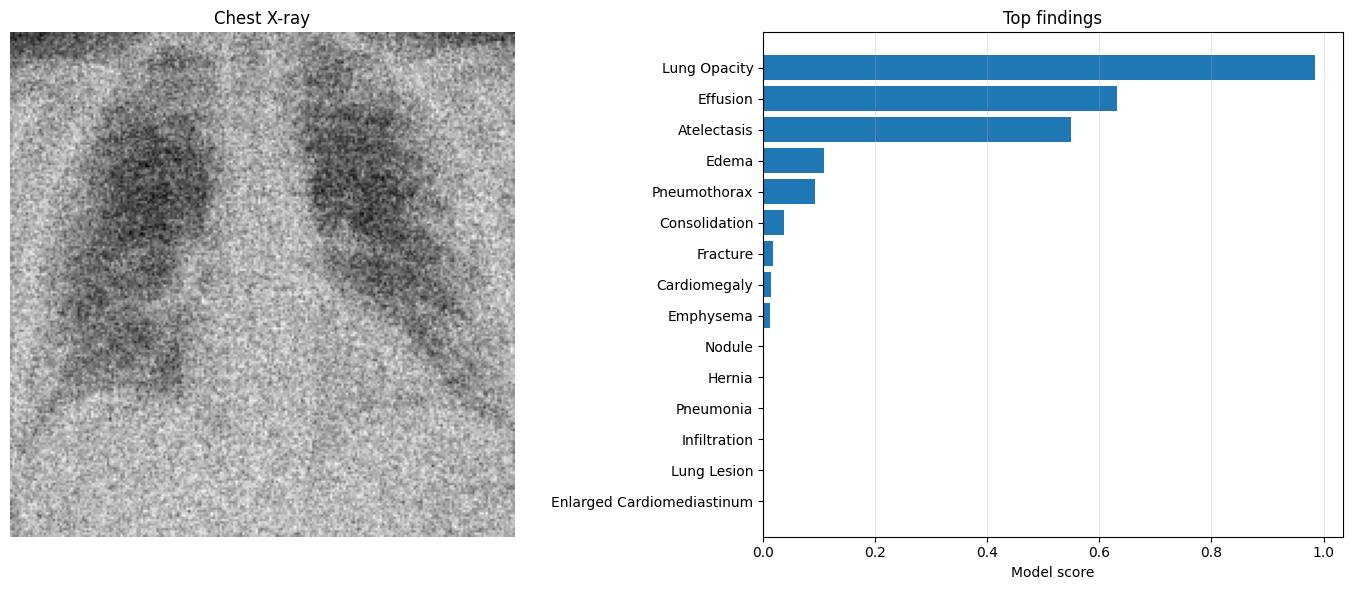

In [220]:
noisy_image = distortions['Gaussian Noise']
scores, indices = predict(noisy_image, model)
visualize_results(noisy_image, scores, indices, top_n=15)

## 8. Pathologies Out-of-Distribution (OOD)

### Exemple: COVID-19

Testons avec des radiographies COVID.

**Dataset**: https://github.com/ieee8023/covid-chestxray-dataset

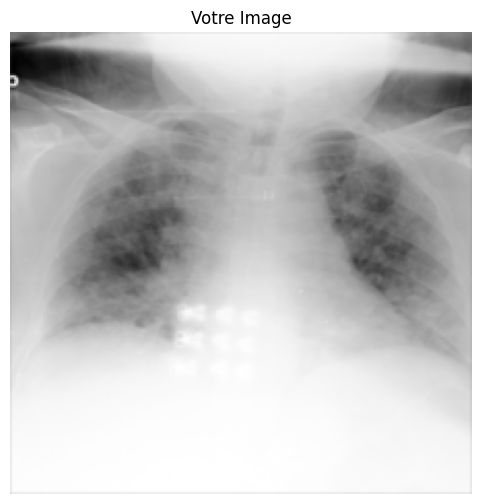

Image COVID-19 téléchargée.
Le modèle n'a JAMAIS vu de COVID pendant l'entraînement.


In [227]:
# Télécharger une radiographie COVID réelle
!wget -q https://raw.githubusercontent.com/ieee8023/covid-chestxray-dataset/master/images/01E392EE-69F9-4E33-BFCE-E5C968654078.jpeg -O covid_xray.jpg

# Préparer l'image
covid_img = prepare_image('covid_xray.jpg', from_file=True)

# Afficher
show_image(covid_img)
print("Image COVID-19 téléchargée.")
print("Le modèle n'a JAMAIS vu de COVID pendant l'entraînement.")


PRÉDICTIONS POUR RADIOGRAPHIE COVID-19
Rappel: Le modèle N'A PAS été entraîné sur COVID!


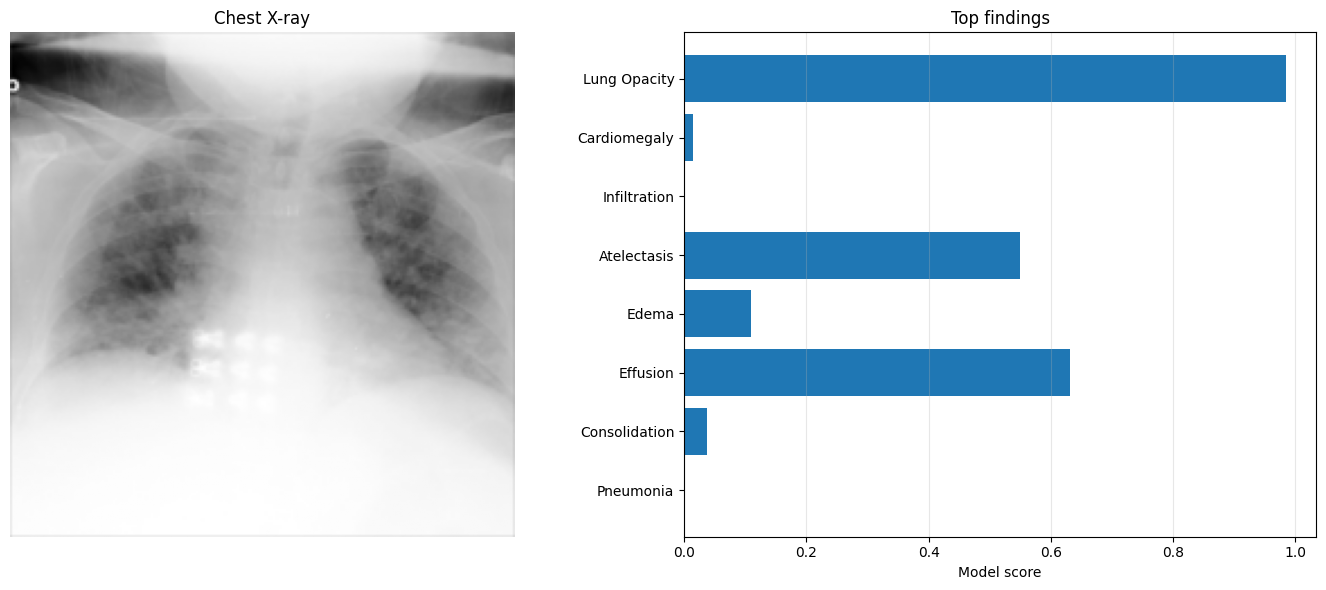


OBSERVATION:
Le modèle mappe COVID vers des catégories connues:


In [226]:
# Analyser l'image COVID
covid_probs, covid_indices = predict(covid_img, model)

print("\nPRÉDICTIONS POUR RADIOGRAPHIE COVID-19")
print("="*55)
print("Rappel: Le modèle N'A PAS été entraîné sur COVID!")
print("="*55)

visualize_results(covid_img, covid_probs, covid_indices, model, top_n=8)

print("\nOBSERVATION:")
print("Le modèle mappe COVID vers des catégories connues:")

## Testez avec vos propres images

In [ ]:
# Upload (ne s'exécute que si dataset non chargé)
from google.colab import files
uploaded = files.upload()
if uploaded:
    img_path = list(uploaded.keys())[0]
    uploaded_img = prepare_image(img_path, from_file=True)
    show_image(uploaded_img)
    print(f"Image chargée: {img_path}")

## 9. Points Clés

### Ce que vous avez appris:
- Charger et analyser des radiographies avec TorchXRayVision
- Utiliser des fonctions réutilisables pour preprocessing et prédictions
- Impact de la qualité d'image sur les prédictions
- Comportement avec pathologies OOD (COVID exemple)

### Applications:
- **Triage**: Prioriser cas urgents
- **Aide au diagnostic**: Détection rapide
- **Recherche**: Analyser grandes cohortes

### Limites importantes:
- **Qualité d'image**: Rotation, bruit, contraste affectent les résultats
- **Pathologies OOD**: Le modèle mappe vers catégories connues
- **Populations**: Entraîné sur certaines populations
- **Outil d'aide**: Ne remplace pas l'expertise médicale

### Bonnes pratiques de code:
- **Fonctions réutilisables**: `prepare_image()`, `predict()`, `display_predictions()`, `visualize_results()`
- **Variables distinctes**: `dataset_img`, `uploaded_img`, `main_img`, `covid_img` évitent les écrasements
- **Modularité**: Chaque fonction a une responsabilité claire